# Data Analysis

In [168]:
from __future__ import annotations

import os
from typing import Sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import yaml
STROKE_TIME_COLS = ['D', 'mu', 'sigma', 'to']
STROKE_GEOM_COLS = ['start_x', 'start_y', 'start_z', 
                    'mid_x', 'mid_y', 'mid_z', 
                    'end_x', 'end_y', 'end_z']
PERFORMANCE_COLS = ['snr_t','snr_v','snr_vr','snr_tr']
ROOT_TO_SAMPLE_DIRS = ['subject', 'task', 'recording', 'stroke_number']

## Database Creation
Each row contains a single stroke. Each stroke can be grouped by:
* Recording
* Task
* Subject

Each stroke contains:
* Analytical characterization:
    * $D$ length param
    * $\log\sigma$ param
    * $\mu$ param
    * $t_0$ param
* Geometrical characterization:
    * $P_{start}$ Virtual target point corresponding to the start of the stroke
    * $P_{mid}$ Middle point that uniquely describes the arc of circumference
    * $P_{end}$ Virtual target point corresponding to the end of the stroke

In [169]:
def create_database(root:str) -> pd.DataFrame:
    """
    Create a database of stroke parameters from CSV files in the given root directory.

    Args:
        root (str): The root directory containing CSV files.
    Returns:
        database (pd.DataFrame): Dafaframe representation of the dataset
    """
    root_folder = os.path.abspath(os.path.join(os.getcwd(), root))
    records = []

    for subject_folder in os.listdir(root_folder):
        if not os.path.isdir(os.path.join(root_folder, subject_folder)):
            continue
        subject_name = os.path.basename(subject_folder)

        for task_folder in os.listdir(os.path.join(root_folder, subject_folder)):
            if not os.path.isdir(os.path.join(root_folder, subject_folder, task_folder)):
                continue
            task_name = os.path.basename(task_folder)

            for csv_file in os.listdir(os.path.join(root_folder, subject_folder, task_folder)):
                if os.path.isdir(os.path.join(root_folder, subject_folder, task_folder, csv_file)):
                    continue
                if csv_file.endswith('logn.csv'):
                    
                    csv_path = os.path.join(root_folder, subject_folder, task_folder, csv_file)
                    recording_number = int(os.path.basename(csv_file).split('_')[1])
                    stroke_data = pd.read_csv(csv_path)

                    for _, row in stroke_data.iterrows():
                        try:
                            record = {
                                'subject': subject_name,
                                'task': task_name,
                                'recording': recording_number,
                                'stroke_number': int(row['stroke']),
                            }
                            for col in STROKE_TIME_COLS + STROKE_GEOM_COLS + PERFORMANCE_COLS:
                                record[col] = row[col]

                            records.append(record)
                        except KeyError as e:
                            print(f"Missing column {e} in file {csv_path}. Skipping this row.")
            

    return pd.DataFrame(records)

In [170]:
CSV_ROOT = 'reconstructed_lognormal_csv'
database = create_database(CSV_ROOT)
database['sigma'] = np.exp(database['sigma'])

database.head(10)
database.head(10)

Missing column 'snr_t' in file /home/ddacunto/Desktop/ros2_ws/reconstructed_lognormal_csv/DAVIDE_DACUNTO/BURST2_XZ/recording_19_logn.csv. Skipping this row.
Missing column 'snr_t' in file /home/ddacunto/Desktop/ros2_ws/reconstructed_lognormal_csv/DAVIDE_DACUNTO/BURST2_XZ/recording_19_logn.csv. Skipping this row.
Missing column 'snr_t' in file /home/ddacunto/Desktop/ros2_ws/reconstructed_lognormal_csv/DAVIDE_DACUNTO/BURST2_XZ/recording_2_logn.csv. Skipping this row.
Missing column 'snr_t' in file /home/ddacunto/Desktop/ros2_ws/reconstructed_lognormal_csv/DAVIDE_DACUNTO/BURST2_XZ/recording_2_logn.csv. Skipping this row.
Missing column 'snr_t' in file /home/ddacunto/Desktop/ros2_ws/reconstructed_lognormal_csv/DAVIDE_DACUNTO/BURST2_XZ/recording_8_logn.csv. Skipping this row.
Missing column 'snr_t' in file /home/ddacunto/Desktop/ros2_ws/reconstructed_lognormal_csv/DAVIDE_DACUNTO/BURST2_XZ/recording_8_logn.csv. Skipping this row.
Missing column 'snr_t' in file /home/ddacunto/Desktop/ros2_ws/

,subject,task,recording,stroke_number,D,mu,sigma,to,start_x,start_y,...,mid_x,mid_y,mid_z,end_x,end_y,end_z,snr_t,snr_v,snr_vr,snr_tr
0,NOEMI_BIANCAMANO,BURST6_YZ,6,1,0.091401,0.098958,0.803742,-0.501,0.005394,-0.048109,...,0.008627,-0.050353,-0.023007,0.011525,-0.035811,0.019939,28.280720,29.710757,29.947034,23.991234
1,NOEMI_BIANCAMANO,BURST6_YZ,6,2,0.094937,0.135216,0.591072,-0.148,0.010857,-0.035814,...,0.015242,-0.003183,0.053393,0.018991,0.042022,0.065312,28.280720,29.710757,29.947034,23.991234
2,NOEMI_BIANCAMANO,BURST6_YZ,6,3,0.086402,0.130485,0.626108,0.030,0.020004,0.041962,...,0.015859,0.059576,0.026493,0.011365,0.056565,-0.015924,28.280720,29.710757,29.947034,23.991234
3,NOEMI_BIANCAMANO,BURST6_YZ,6,4,0.060620,0.114048,0.557139,0.205,0.008462,0.056555,...,0.007219,0.047935,-0.044489,0.008529,0.029866,-0.068581,28.280720,29.710757,29.947034,23.991234
4,NOEMI_BIANCAMANO,BURST6_YZ,16,1,0.171929,0.102050,0.830403,-0.501,0.004715,-0.053202,...,0.008046,-0.022634,0.014925,0.021583,0.038918,0.072239,21.587438,17.678575,17.743491,23.442616
5,NOEMI_BIANCAMANO,BURST6_YZ,16,2,0.151849,0.141524,0.670916,-0.068,0.026920,0.037422,...,0.026197,0.065600,0.003018,0.028871,0.055327,-0.071287,21.587438,17.678575,17.743491,23.442616
6,NOEMI_BIANCAMANO,BURST6_YZ,19,1,0.203540,0.113555,0.868362,-0.502,0.003733,-0.050954,...,0.023800,-0.016657,0.014601,0.046421,0.048339,0.088833,22.890609,22.978307,23.158205,23.381996
7,NOEMI_BIANCAMANO,BURST6_YZ,19,2,0.162610,0.121091,0.646252,-0.025,0.047478,0.048157,...,0.032039,0.062448,0.010443,0.028332,0.055463,-0.070166,22.890609,22.978307,23.158205,23.381996
8,NOEMI_BIANCAMANO,BURST6_YZ,17,1,0.212536,0.146394,0.732838,-0.502,0.000943,-0.055138,...,0.013645,-0.009379,0.029836,0.033862,0.066116,0.100967,19.636338,22.323366,22.403972,24.857293
9,NOEMI_BIANCAMANO,BURST6_YZ,17,2,0.184715,0.128430,0.666312,-0.120,0.033857,0.066117,...,0.017771,0.062153,0.010319,0.018948,0.044112,-0.080021,19.636338,22.323366,22.403972,24.857293


### Number of waypoints for each task

In [171]:
PATH_TO_PATHS_FILE = os.path.join(os.getcwd(), 'src', 'unisa_acg_ros2', 'haptics', 'haptic_interaction_teach_and_record_demo', 'config', 'paths.yaml')
if not os.path.exists(PATH_TO_PATHS_FILE):
    raise FileNotFoundError(f"Paths file not found: {PATH_TO_PATHS_FILE}")

WAYPOINTS_BY_TASK = {}
with open(PATH_TO_PATHS_FILE, 'r') as f:
    paths_data = yaml.safe_load(f)
    print(f"Loaded paths data: {paths_data['paths']}")
    for path in paths_data['paths']:
        WAYPOINTS_BY_TASK[path['name']] = len(path['waypoints'])

WAYPOINTS_BY_TASK

Loaded paths data: [{'name': 'BURST1_XY', 'waypoints': [{'x': 0.2, 'y': 0.2, 'z': 0.5}, {'x': 0.8, 'y': 0.8, 'z': 0.5}]}, {'name': 'BURST2_XZ', 'waypoints': [{'x': 0.2, 'y': 0.5, 'z': 0.2}, {'x': 0.8, 'y': 0.5, 'z': 0.8}]}, {'name': 'BURST3_YZ', 'waypoints': [{'x': 0.5, 'y': 0.2, 'z': 0.2}, {'x': 0.5, 'y': 0.8, 'z': 0.8}]}, {'name': 'BURST4_XY', 'waypoints': [{'x': 0.1, 'y': 0.2, 'z': 0.5}, {'x': 0.9, 'y': 0.5, 'z': 0.5}, {'x': 0.1, 'y': 0.8, 'z': 0.5}]}, {'name': 'BURST5_XZ', 'waypoints': [{'x': 0.2, 'y': 0.5, 'z': 0.1}, {'x': 0.5, 'y': 0.5, 'z': 0.9}, {'x': 0.8, 'y': 0.5, 'z': 0.1}]}, {'name': 'BURST6_YZ', 'waypoints': [{'x': 0.5, 'y': 0.1, 'z': 0.2}, {'x': 0.5, 'y': 0.9, 'z': 0.5}, {'x': 0.5, 'y': 0.1, 'z': 0.8}]}, {'name': 'GEOMETRIC1_SPIRAL_3DY', 'waypoints': [{'x': 0.2, 'y': 0.26, 'z': 0.5}, {'x': 0.5, 'y': 0.42, 'z': 0.2}, {'x': 0.8, 'y': 0.58, 'z': 0.5}, {'x': 0.5, 'y': 0.74, 'z': 0.8}, {'x': 0.2, 'y': 0.9, 'z': 0.5}]}, {'name': 'GEOMETRIC2_SPIRAL_3DX', 'waypoints': [{'x': 0.74

{'BURST1_XY': 2,
 'BURST2_XZ': 2,
 'BURST3_YZ': 2,
 'BURST4_XY': 3,
 'BURST5_XZ': 3,
 'BURST6_YZ': 3,
 'GEOMETRIC1_SPIRAL_3DY': 5,
 'GEOMETRIC2_SPIRAL_3DX': 5,
 'GEOMETRIC3_SPIRAL_XY': 6,
 'GEOMETRIC4_CIRCLE_XY': 5,
 'GEOMETRIC5_CIRCLE_ZX': 5,
 'GEOMETRIC6_ELLIPSE_XY': 5,
 'GEOMETRIC7_ELLIPSE_XZ': 5,
 'LETTER1_L': 5,
 'LETTER2_PHI': 6,
 'LETTER3_S': 4,
 'LETTER4_N': 4}

### \[TODO\] Drop unavailable tasks

In [172]:
TASKS_TO_DROP = []
TASKS_TO_DROP = ['LETTER2_PHI'] + sorted(
    set(WAYPOINTS_BY_TASK.keys()) - set(database.loc[database['subject'] == 'NOEMI_BIANCAMANO', 'task'])
)

database = database[~database['task'].isin(TASKS_TO_DROP)]
database = database.reset_index(drop=True)
database.head(10)

,subject,task,recording,stroke_number,D,mu,sigma,to,start_x,start_y,...,mid_x,mid_y,mid_z,end_x,end_y,end_z,snr_t,snr_v,snr_vr,snr_tr
0,NOEMI_BIANCAMANO,BURST6_YZ,6,1,0.091401,0.098958,0.803742,-0.501,0.005394,-0.048109,...,0.008627,-0.050353,-0.023007,0.011525,-0.035811,0.019939,28.280720,29.710757,29.947034,23.991234
1,NOEMI_BIANCAMANO,BURST6_YZ,6,2,0.094937,0.135216,0.591072,-0.148,0.010857,-0.035814,...,0.015242,-0.003183,0.053393,0.018991,0.042022,0.065312,28.280720,29.710757,29.947034,23.991234
2,NOEMI_BIANCAMANO,BURST6_YZ,6,3,0.086402,0.130485,0.626108,0.030,0.020004,0.041962,...,0.015859,0.059576,0.026493,0.011365,0.056565,-0.015924,28.280720,29.710757,29.947034,23.991234
3,NOEMI_BIANCAMANO,BURST6_YZ,6,4,0.060620,0.114048,0.557139,0.205,0.008462,0.056555,...,0.007219,0.047935,-0.044489,0.008529,0.029866,-0.068581,28.280720,29.710757,29.947034,23.991234
4,NOEMI_BIANCAMANO,BURST6_YZ,16,1,0.171929,0.102050,0.830403,-0.501,0.004715,-0.053202,...,0.008046,-0.022634,0.014925,0.021583,0.038918,0.072239,21.587438,17.678575,17.743491,23.442616
5,NOEMI_BIANCAMANO,BURST6_YZ,16,2,0.151849,0.141524,0.670916,-0.068,0.026920,0.037422,...,0.026197,0.065600,0.003018,0.028871,0.055327,-0.071287,21.587438,17.678575,17.743491,23.442616
6,NOEMI_BIANCAMANO,BURST6_YZ,19,1,0.203540,0.113555,0.868362,-0.502,0.003733,-0.050954,...,0.023800,-0.016657,0.014601,0.046421,0.048339,0.088833,22.890609,22.978307,23.158205,23.381996
7,NOEMI_BIANCAMANO,BURST6_YZ,19,2,0.162610,0.121091,0.646252,-0.025,0.047478,0.048157,...,0.032039,0.062448,0.010443,0.028332,0.055463,-0.070166,22.890609,22.978307,23.158205,23.381996
8,NOEMI_BIANCAMANO,BURST6_YZ,17,1,0.212536,0.146394,0.732838,-0.502,0.000943,-0.055138,...,0.013645,-0.009379,0.029836,0.033862,0.066116,0.100967,19.636338,22.323366,22.403972,24.857293
9,NOEMI_BIANCAMANO,BURST6_YZ,17,2,0.184715,0.128430,0.666312,-0.120,0.033857,0.066117,...,0.017771,0.062153,0.010319,0.018948,0.044112,-0.080021,19.636338,22.323366,22.403972,24.857293


## Data Overview

In [173]:
SUBJECTS = database['subject'].unique()

for subject in SUBJECTS:
    print(f"Subject: {subject}, samples: ", database[database['subject'] == subject].shape[0])

Subject: NOEMI_BIANCAMANO, samples:  1315
Subject: DAVIDE_DACUNTO, samples:  625
Subject: LUCIA_DE_LUCIA, samples:  1797


In [174]:
TASKS = database['task'].unique()

for task in TASKS:
    print(f"Task: {task}, samples: ", database[database['task'] == task].shape[0])

Task: BURST6_YZ, samples:  256
Task: GEOMETRIC3_SPIRAL_XY, samples:  636
Task: BURST2_XZ, samples:  87
Task: GEOMETRIC4_CIRCLE_XY, samples:  558
Task: GEOMETRIC5_CIRCLE_ZX, samples:  412
Task: BURST5_XZ, samples:  163
Task: GEOMETRIC1_SPIRAL_3DY, samples:  681
Task: BURST1_XY, samples:  109
Task: GEOMETRIC2_SPIRAL_3DX, samples:  650
Task: BURST3_YZ, samples:  59
Task: BURST4_XY, samples:  126


### Distribution of `STROKE_TIME_COLS` parameters

#### Total

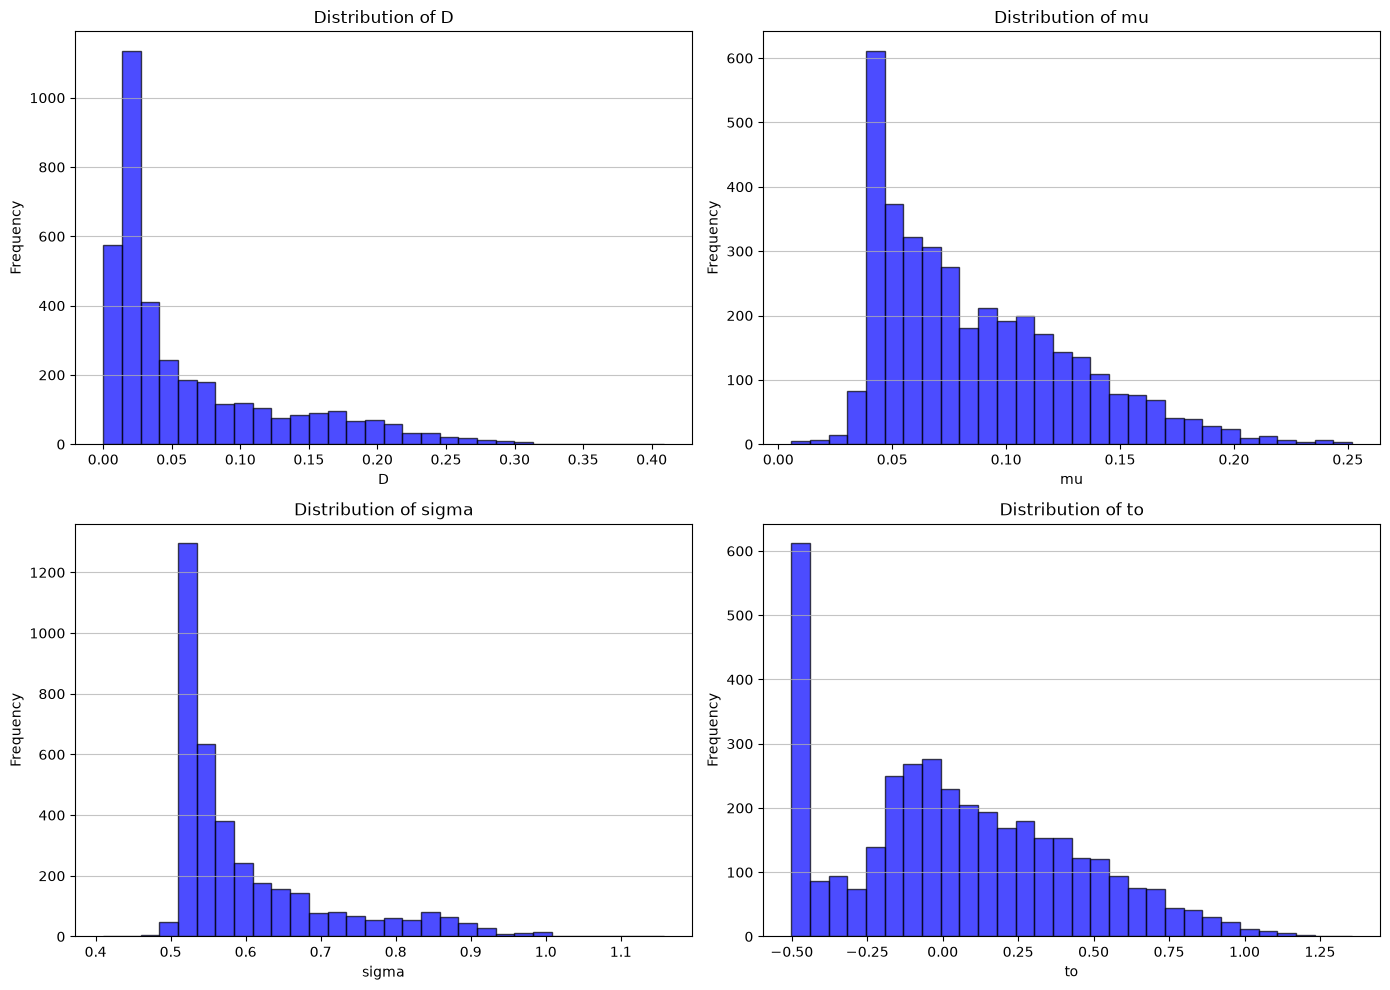

In [175]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, col in zip(axes, STROKE_TIME_COLS):
    ax.hist(database[col], bins=30, alpha=0.7, color='blue', edgecolor='black')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

#### By task

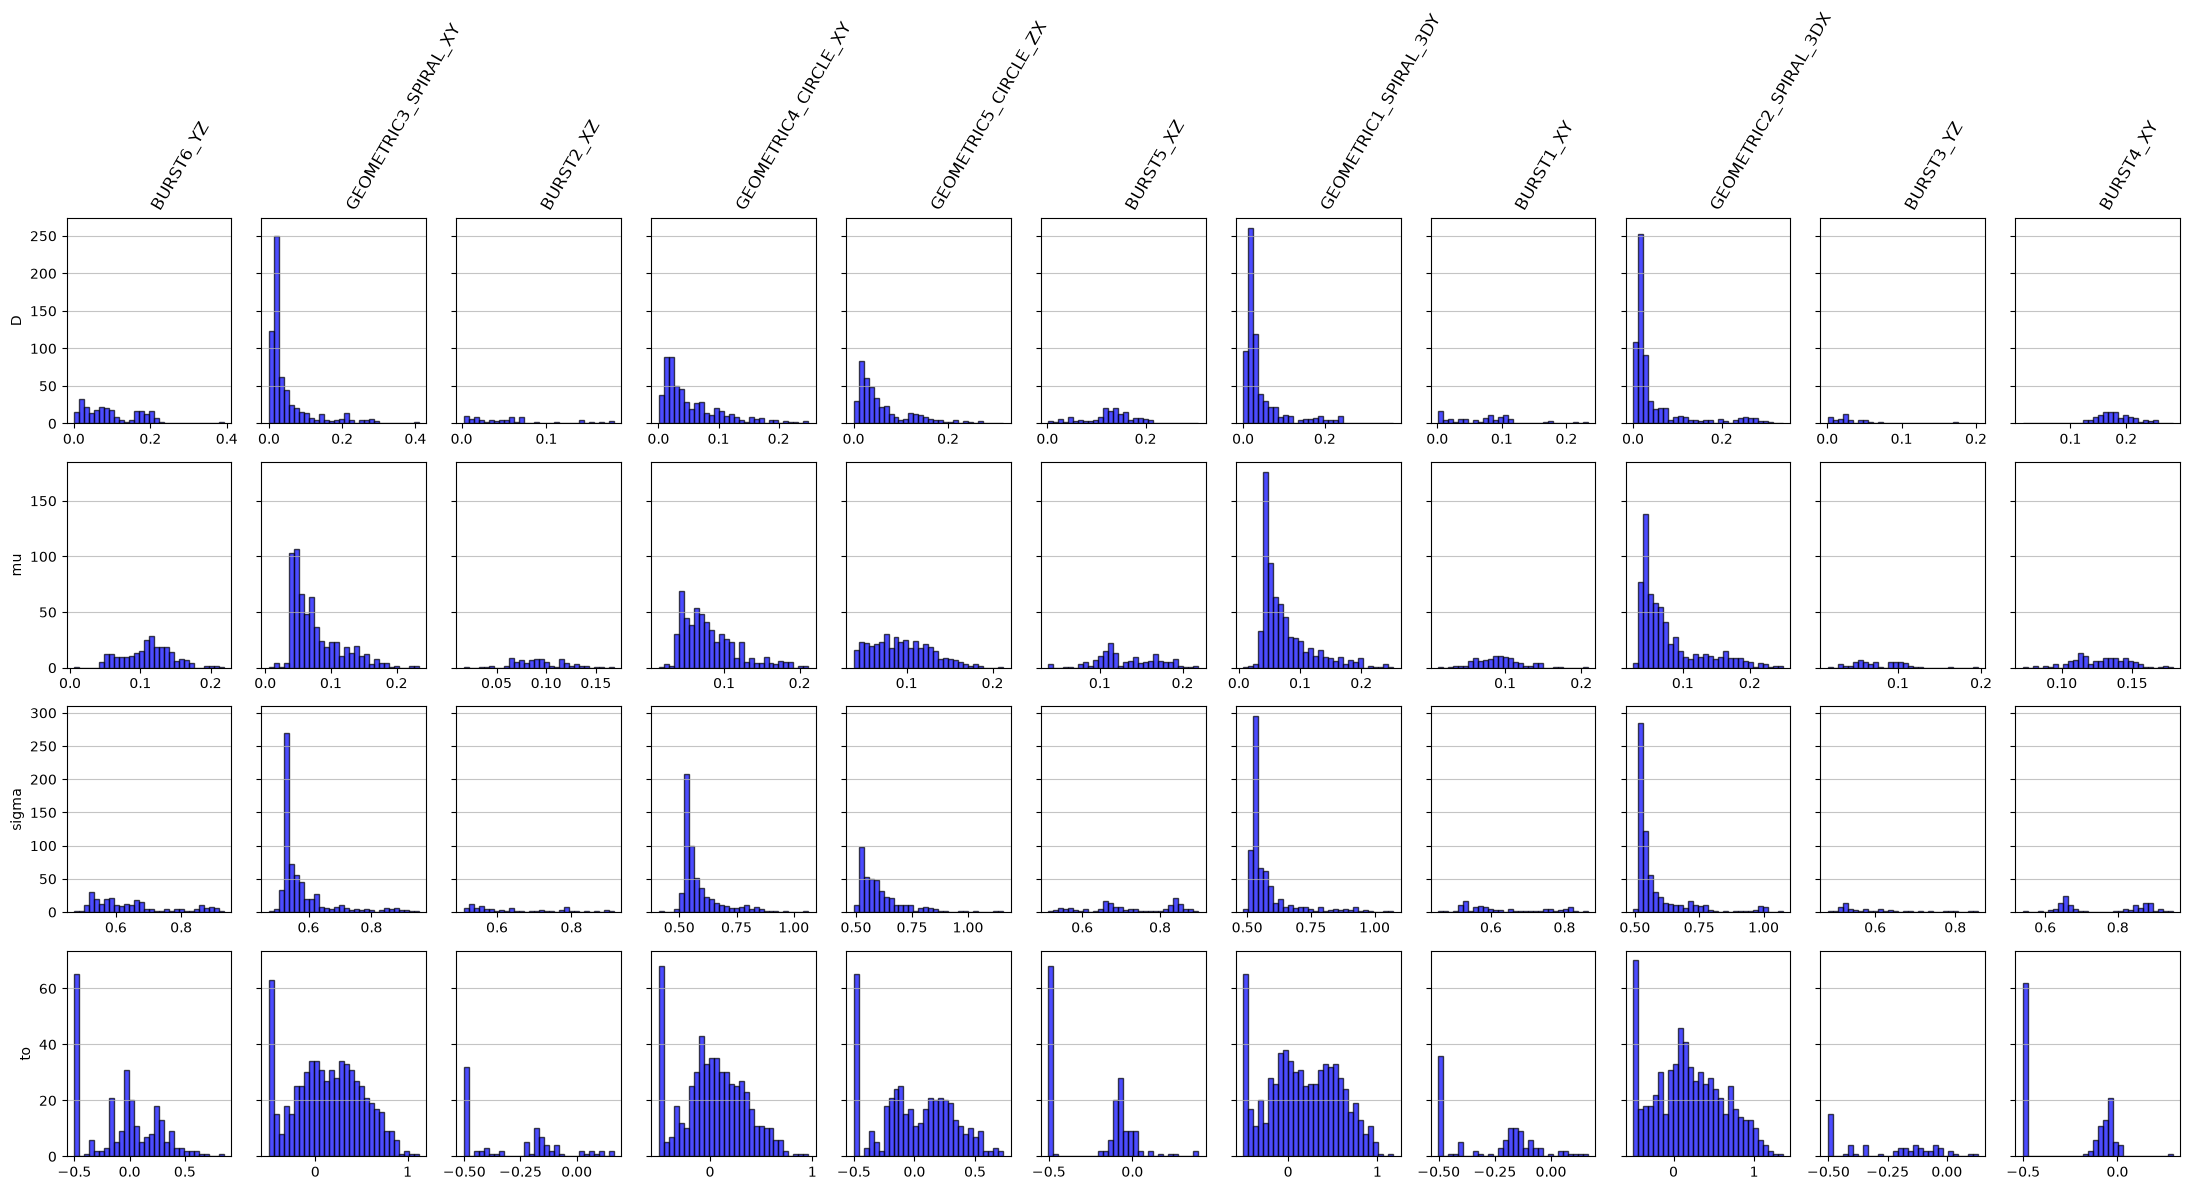

In [176]:

fig, axes = plt.subplots(
    len(STROKE_TIME_COLS),
    len(TASKS),
    figsize=(2 * len(TASKS), 12),
    sharey='row',
    squeeze=False
)

for task_idx, task in enumerate(TASKS):
    task_data = database[database['task'] == task]

    for col_idx, col in enumerate(STROKE_TIME_COLS):
        ax = axes[col_idx, task_idx]
        ax.hist(
            task_data[col],
            bins=30,
            alpha=0.7,
            color='blue',
            edgecolor='black'
        )

        if col_idx == 0:
            ax.set_title(task, rotation=60, ha='left')

        #ax.set_xlabel(col)
        ax.grid(axis='y', alpha=0.75)

        if task_idx == 0:
            ax.set_ylabel(col)

plt.tight_layout()
plt.show()

#### By subject

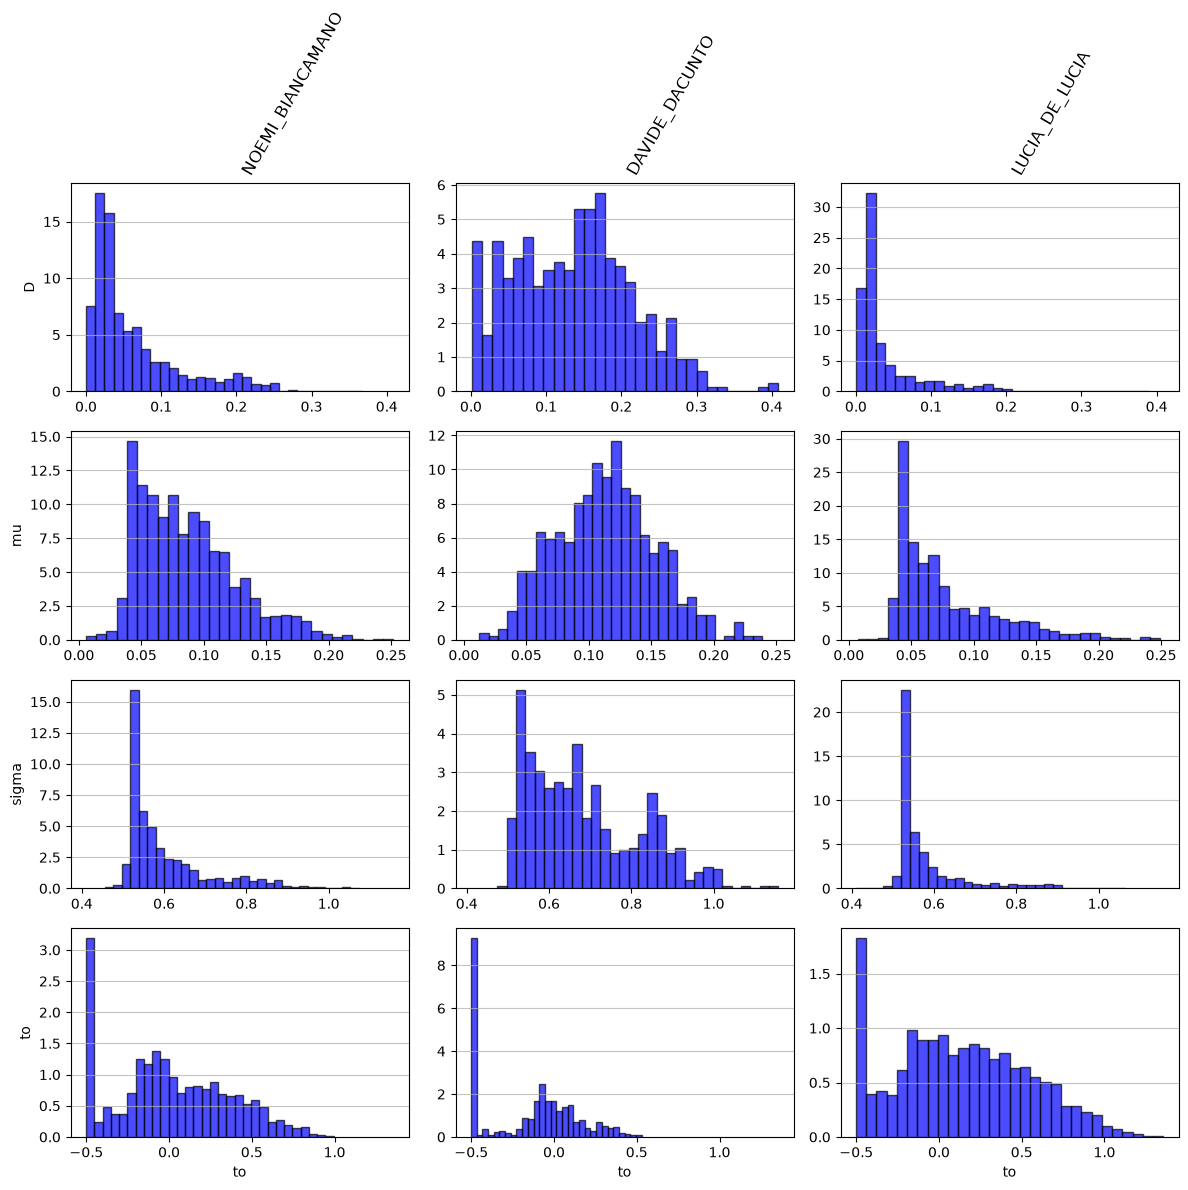

In [177]:
fig, axes = plt.subplots(
    len(STROKE_TIME_COLS),
    len(SUBJECTS),
    figsize=(4 * len(SUBJECTS), 12),
    sharex='row',
    #sharey='row',
    squeeze=False
)


for subject_idx, subject in enumerate(SUBJECTS):
    subject_data = database[database['subject'] == subject]

    for col_idx, col in enumerate(STROKE_TIME_COLS):
        ax = axes[col_idx, subject_idx]

        ax.hist(
            subject_data[col].dropna(),
            bins=30,
            alpha=0.7,
            color='blue',
            edgecolor='black',
            density=True
        )

        if col_idx == 0:
            ax.set_title(subject, rotation=60, ha='left')

        if col_idx == len(STROKE_TIME_COLS) - 1:
            ax.set_xlabel(col)

        if subject_idx == 0:
            ax.set_ylabel(col)

        ax.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

### Stroke count

#### For each subject by task

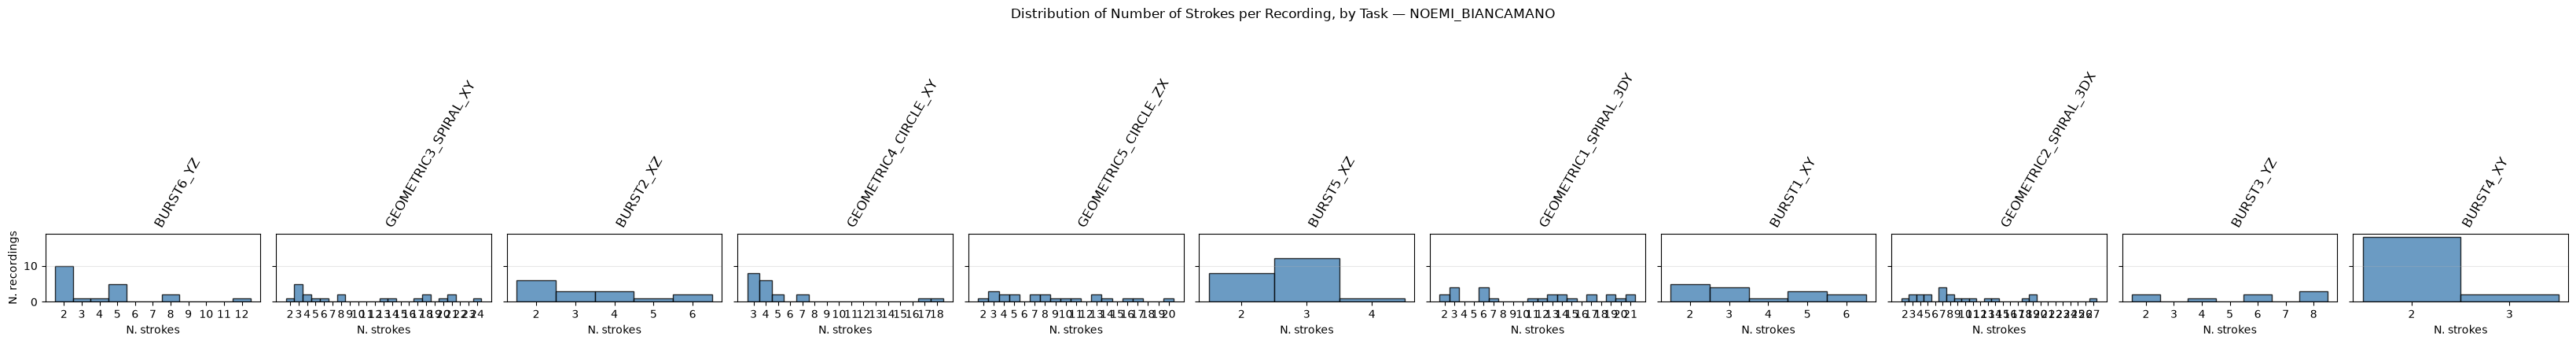

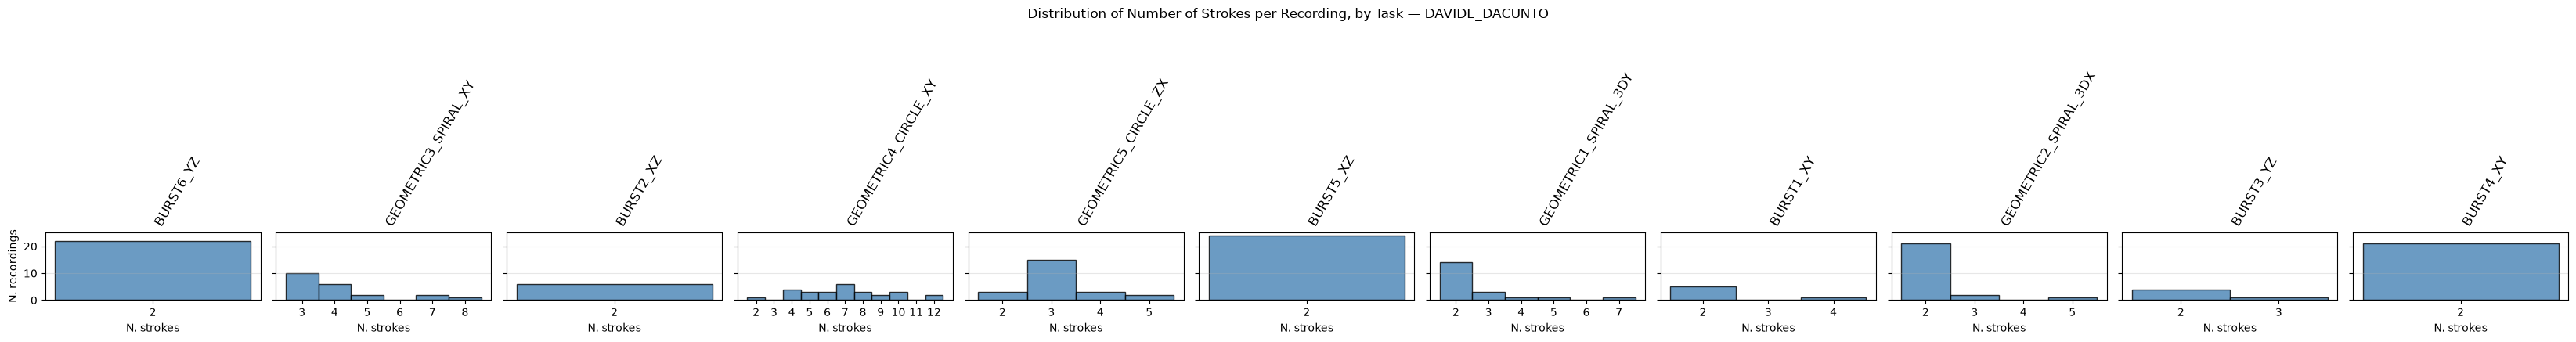

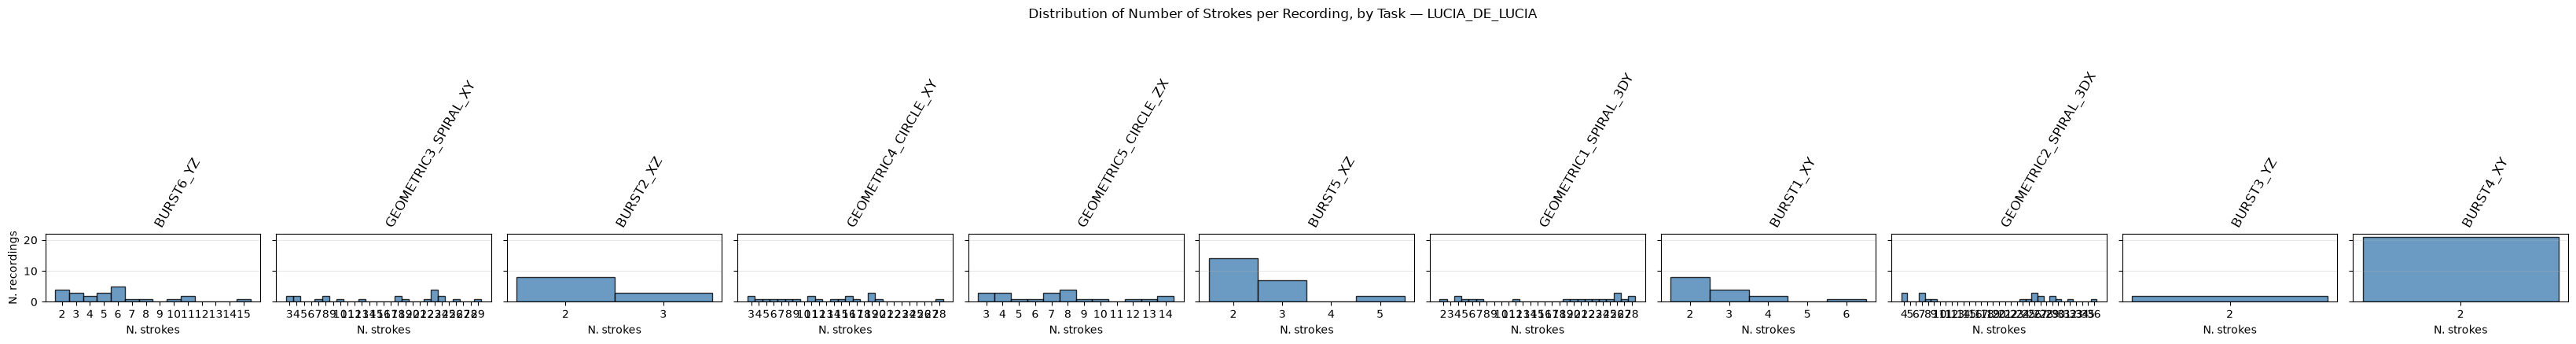

In [178]:
recording_stroke_counts = (
    database
    .groupby(['subject', 'task', 'recording'])
    .size()
    .reset_index(name='stroke_count')
)

for subject in SUBJECTS:
    subject_data = recording_stroke_counts[recording_stroke_counts['subject'] == subject]

    fig, axes = plt.subplots(
        1, len(TASKS),
        figsize=(3 * len(TASKS), 4),
        sharey=True,
        squeeze=False
    )
    axes = axes[0]

    for task_idx, task in enumerate(TASKS):
        ax = axes[task_idx]
        task_counts = subject_data.loc[subject_data['task'] == task, 'stroke_count']

        if len(task_counts) > 0:
            bins = np.arange(task_counts.min(), task_counts.max() + 2) - 0.5
            ax.hist(task_counts, bins=bins, color='steelblue', edgecolor='black', alpha=0.8)
            ax.set_xticks(range(int(task_counts.min()), int(task_counts.max()) + 1))

        ax.set_title(task, rotation=60, ha='left')
        ax.set_xlabel('N. strokes')
        ax.grid(axis='y', alpha=0.3)

    axes[0].set_ylabel('N. recordings')
    plt.suptitle(f'Distribution of Number of Strokes per Recording, by Task — {subject}', y=1.08)
    plt.tight_layout()
    plt.show()


### For each subject by task waypoints count

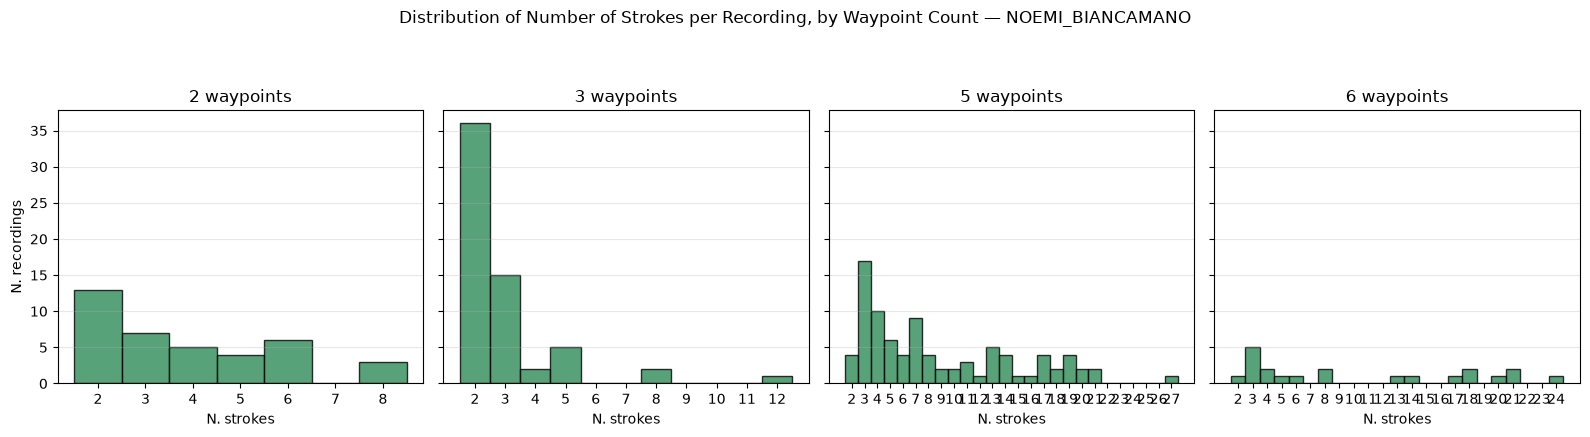

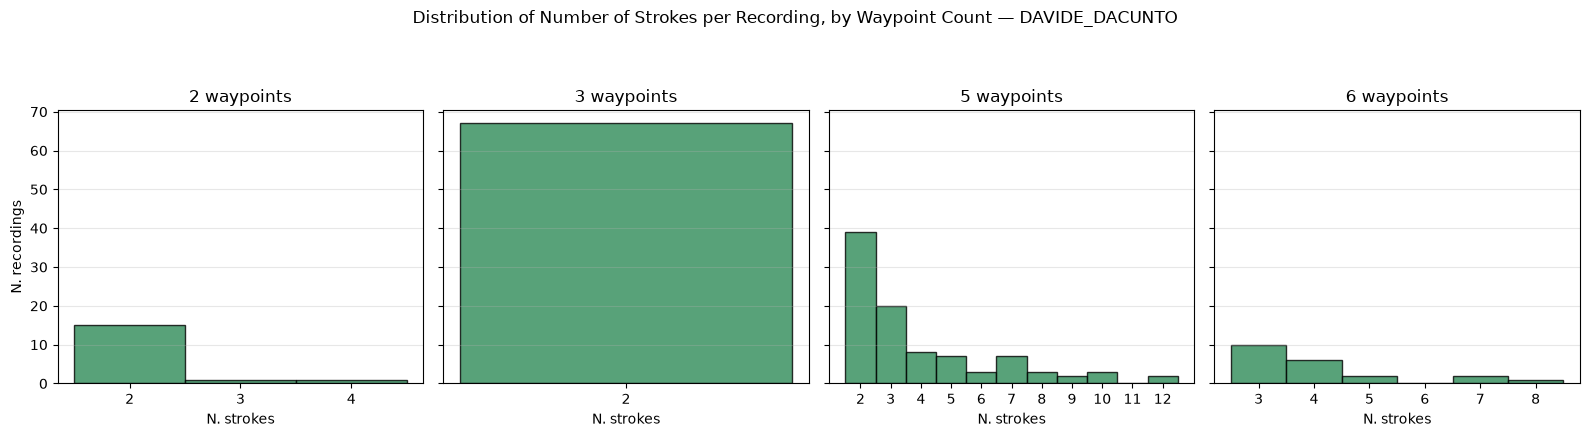

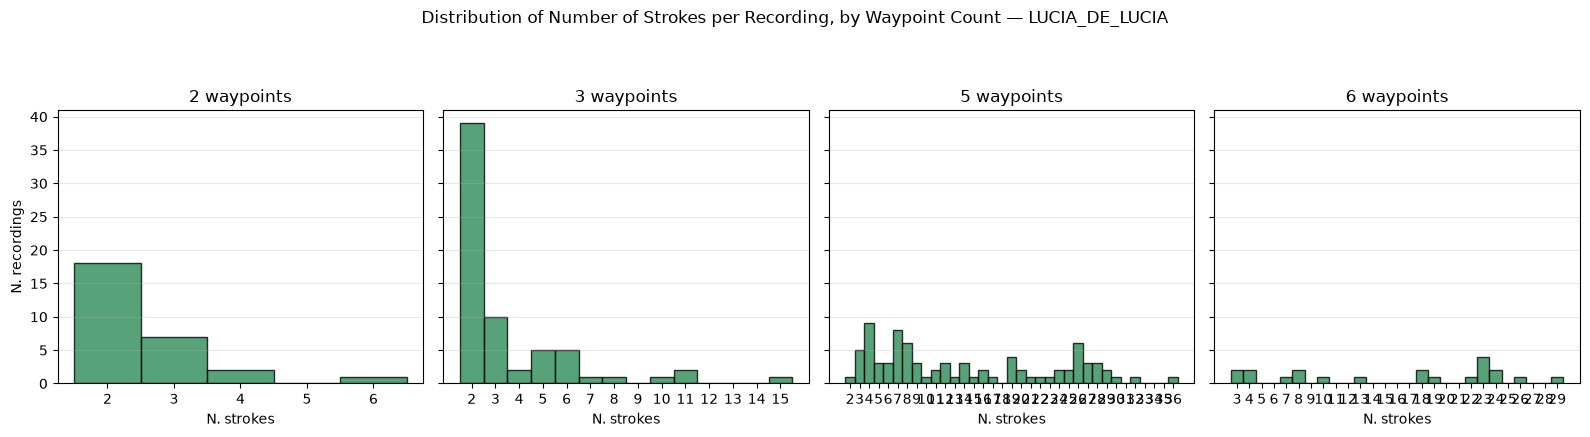

In [179]:
recording_stroke_counts_wp = recording_stroke_counts.assign(
    waypoint_count=recording_stroke_counts['task'].map(WAYPOINTS_BY_TASK)
)

WAYPOINT_COUNTS = sorted(recording_stroke_counts_wp['waypoint_count'].dropna().unique())

for subject in SUBJECTS:
    subject_data = recording_stroke_counts_wp[recording_stroke_counts_wp['subject'] == subject]

    fig, axes = plt.subplots(
        1, len(WAYPOINT_COUNTS),
        figsize=(4 * len(WAYPOINT_COUNTS), 4),
        sharey=True,
        squeeze=False
    )
    axes = axes[0]

    for wp_idx, wp_count in enumerate(WAYPOINT_COUNTS):
        ax = axes[wp_idx]
        wp_counts = subject_data.loc[subject_data['waypoint_count'] == wp_count, 'stroke_count']

        if len(wp_counts) > 0:
            bins = np.arange(wp_counts.min(), wp_counts.max() + 2) - 0.5
            ax.hist(wp_counts, bins=bins, color='seagreen', edgecolor='black', alpha=0.8)
            ax.set_xticks(range(int(wp_counts.min()), int(wp_counts.max()) + 1))

        ax.set_title(f'{int(wp_count)} waypoints')
        ax.set_xlabel('N. strokes')
        ax.grid(axis='y', alpha=0.3)

    axes[0].set_ylabel('N. recordings')
    plt.suptitle(f'Distribution of Number of Strokes per Recording, by Waypoint Count — {subject}', y=1.08)
    plt.tight_layout()
    plt.show()


## Statistical Comparison Across Subjects

### Distribution comparison
Overlaid, density-normalized histograms of each lognormal parameter, split by subject.

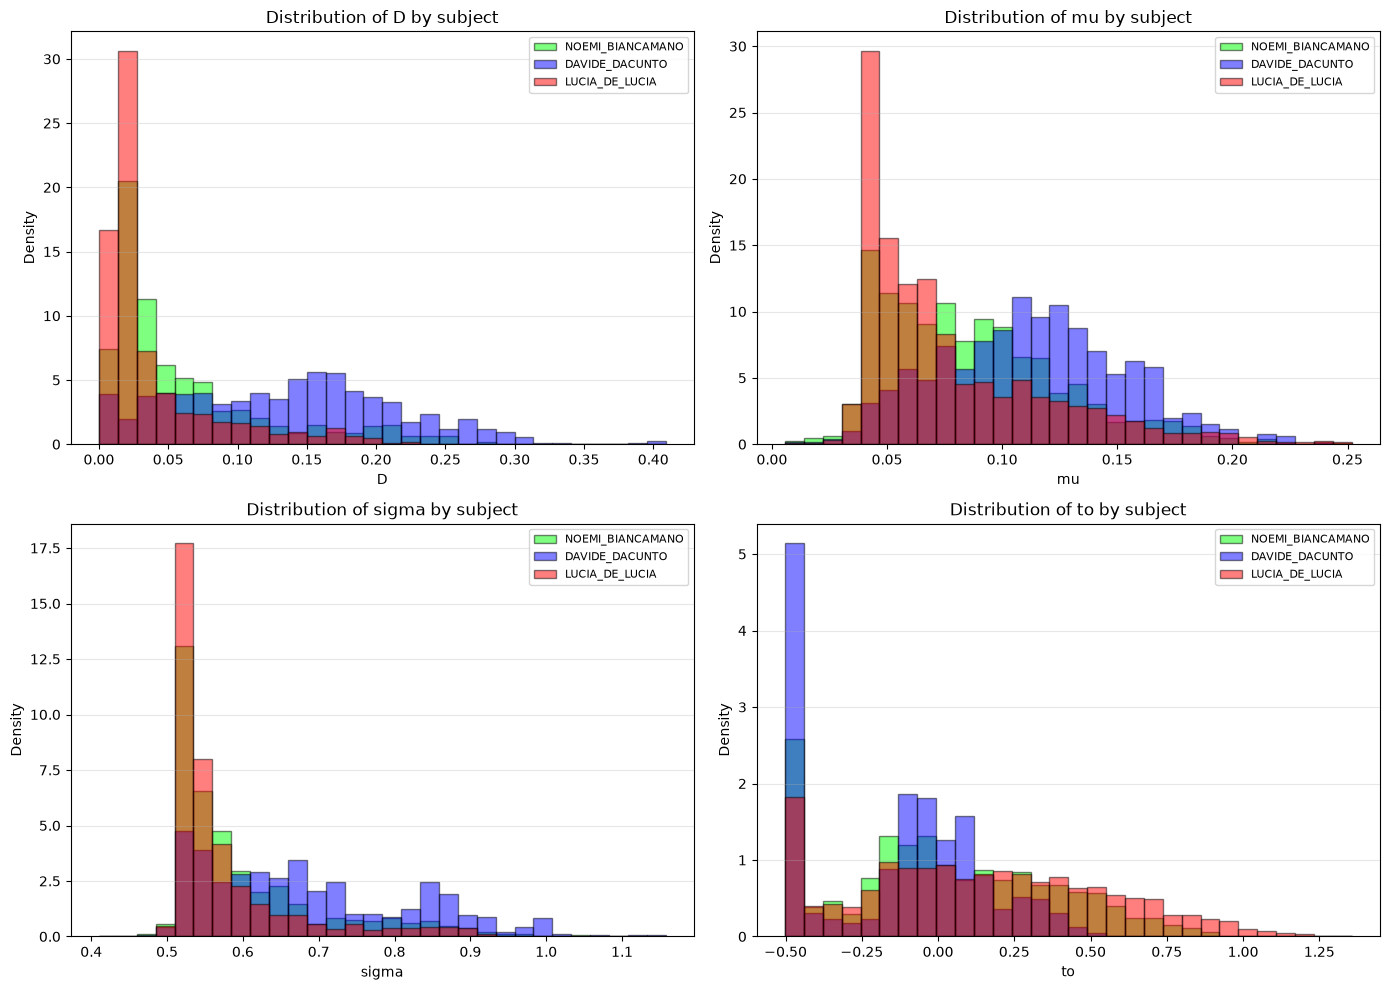

In [180]:
SUBJECT_COLORS = ['#00ff00', '#0000ff', '#ff0000']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, col in zip(axes, STROKE_TIME_COLS):
    col_values = database[col].dropna()
    bin_edges = np.linspace(col_values.min(), col_values.max(), 31)

    for subject, color in zip(SUBJECTS, SUBJECT_COLORS):
        subject_values = database.loc[database['subject'] == subject, col].dropna()
        ax.hist(
            subject_values,
            bins=bin_edges,
            density=True,
            alpha=0.5,
            color=color,
            edgecolor='black',
            label=subject
        )

    ax.set_title(f'Distribution of {col} by subject')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


### Normality test (Shapiro-Wilk) by subject
For each subject and each lognormal parameter, tests $H_0$: the sample comes from a normal distribution.

In [181]:
normality_results = []

for subject in SUBJECTS:
    subject_data = database[database['subject'] == subject]
    for col in STROKE_TIME_COLS:
        values = subject_data[col].dropna()
        stat, p_value = stats.shapiro(values)
        normality_results.append({
            'subject': subject,
            'parameter': col,
            'n': len(values),
            'shapiro_W': stat,
            'p_value': p_value,
            'normal (alpha=0.05)': p_value > 0.05
        })

normality_df = pd.DataFrame(normality_results)
normality_df


,subject,parameter,n,shapiro_W,p_value,normal (alpha=0.05)
0,NOEMI_BIANCAMANO,D,1315,0.803045,3.046066e-37,False
1,NOEMI_BIANCAMANO,mu,1315,0.943001,4.268284e-22,False
2,NOEMI_BIANCAMANO,sigma,1315,0.786533,2.272898e-38,False
3,NOEMI_BIANCAMANO,to,1315,0.961355,3.338905e-18,False
4,DAVIDE_DACUNTO,D,625,0.978669,6.689252e-08,False
5,DAVIDE_DACUNTO,mu,625,0.994331,1.986623e-02,False
6,DAVIDE_DACUNTO,sigma,625,0.931735,2.801870e-16,False
7,DAVIDE_DACUNTO,to,625,0.893157,2.054246e-20,False
8,LUCIA_DE_LUCIA,D,1797,0.690980,2.685766e-49,False
9,LUCIA_DE_LUCIA,mu,1797,0.840879,4.098048e-39,False


### Pairwise t-test between subjects
Welch's t-test (does not assume equal variances) for each parameter, on every pair of subjects.

In [182]:
from itertools import combinations

ttest_results = []

for col in STROKE_TIME_COLS:
    for subj_a, subj_b in combinations(SUBJECTS, 2):
        data_a = database.loc[database['subject'] == subj_a, col].dropna()
        data_b = database.loc[database['subject'] == subj_b, col].dropna()

        stat, p_value = stats.ttest_ind(data_a, data_b, equal_var=False)  # Welch's t-test

        ttest_results.append({
            'parameter': col,
            'subject_A': subj_a,
            'subject_B': subj_b,
            'mean_A': data_a.mean(),
            'mean_B': data_b.mean(),
            't_stat': stat,
            'p_value': p_value,
            'significant (alpha=0.05)': p_value < 0.05
        })

ttest_df = pd.DataFrame(ttest_results)
ttest_df


,parameter,subject_A,subject_B,mean_A,mean_B,t_stat,p_value,significant (alpha=0.05)
0,D,NOEMI_BIANCAMANO,DAVIDE_DACUNTO,0.062448,0.135571,-20.652406,3.831609e-79,True
1,D,NOEMI_BIANCAMANO,LUCIA_DE_LUCIA,0.062448,0.038639,12.061050,1.605390e-32,True
2,D,DAVIDE_DACUNTO,LUCIA_DE_LUCIA,0.135571,0.038639,29.446317,3.245684e-128,True
3,mu,NOEMI_BIANCAMANO,DAVIDE_DACUNTO,0.086552,0.113300,-13.942049,4.368813e-41,True
4,mu,NOEMI_BIANCAMANO,LUCIA_DE_LUCIA,0.086552,0.077276,6.389671,1.929231e-10,True
5,mu,DAVIDE_DACUNTO,LUCIA_DE_LUCIA,0.113300,0.077276,19.367614,2.427089e-72,True
6,sigma,NOEMI_BIANCAMANO,DAVIDE_DACUNTO,0.599926,0.685145,-13.979498,1.376488e-40,True
7,sigma,NOEMI_BIANCAMANO,LUCIA_DE_LUCIA,0.599926,0.575150,7.165705,1.008749e-12,True
8,sigma,DAVIDE_DACUNTO,LUCIA_DE_LUCIA,0.685145,0.575150,19.012066,7.047192e-67,True
9,to,NOEMI_BIANCAMANO,DAVIDE_DACUNTO,0.016065,-0.148922,11.000948,4.000265e-27,True


## $\sigma$ average weighted over $D$
For each subject:
$$\sigma_w = \frac{\sum_i D_i \cdot \sigma_i}{\sum_i D_i}$$


In [183]:
weighted_sigma_by_recording = (
    database
    .groupby(['subject', 'task', 'recording'])
    .apply(lambda g: np.average(g['sigma'], weights=g['D']))
    .reset_index(name='sigma_D_weighted')
)

weighted_sigma_by_recording.head(10)


,subject,task,recording,sigma_D_weighted
0,DAVIDE_DACUNTO,BURST1_XY,0,0.707120
1,DAVIDE_DACUNTO,BURST1_XY,1,0.795306
2,DAVIDE_DACUNTO,BURST1_XY,2,0.792720
3,DAVIDE_DACUNTO,BURST1_XY,9,0.717295
4,DAVIDE_DACUNTO,BURST1_XY,10,0.731027
5,DAVIDE_DACUNTO,BURST1_XY,14,0.608962
6,DAVIDE_DACUNTO,BURST2_XZ,4,0.657426
7,DAVIDE_DACUNTO,BURST2_XZ,5,0.713351
8,DAVIDE_DACUNTO,BURST2_XZ,6,0.717356
9,DAVIDE_DACUNTO,BURST2_XZ,14,0.714531


### Distribuzione di σ pesata tra soggetti

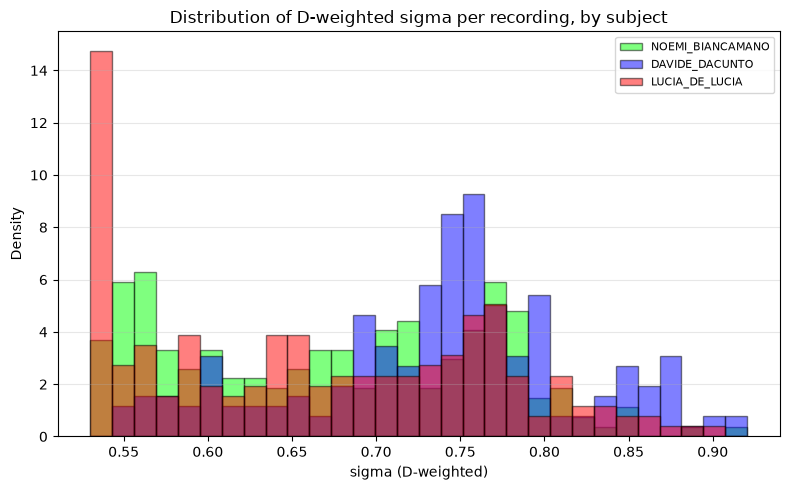

In [184]:
fig, ax = plt.subplots(figsize=(8, 5))

col_values = weighted_sigma_by_recording['sigma_D_weighted'].dropna()
bin_edges = np.linspace(col_values.min(), col_values.max(), 31)

for subject, color in zip(SUBJECTS, SUBJECT_COLORS):
    subject_values = weighted_sigma_by_recording.loc[
        weighted_sigma_by_recording['subject'] == subject, 'sigma_D_weighted'
    ].dropna()
    ax.hist(
        subject_values,
        bins=bin_edges,
        density=True,
        alpha=0.5,
        color=color,
        edgecolor='black',
        label=subject
    )

ax.set_title('Distribution of D-weighted sigma per recording, by subject')
ax.set_xlabel('sigma (D-weighted)')
ax.set_ylabel('Density')
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


### Normality test (Shapiro-Wilk) over weighted $\sigma$

In [185]:
weighted_sigma_normality_results = []

for subject in SUBJECTS:
    values = weighted_sigma_by_recording.loc[
        weighted_sigma_by_recording['subject'] == subject, 'sigma_D_weighted'
    ].dropna()
    stat, p_value = stats.shapiro(values)
    weighted_sigma_normality_results.append({
        'subject': subject,
        'parameter': 'sigma_D_weighted',
        'n': len(values),
        'shapiro_W': stat,
        'p_value': p_value,
        'normal (alpha=0.05)': p_value > 0.05
    })

weighted_sigma_normality_df = pd.DataFrame(weighted_sigma_normality_results)
weighted_sigma_normality_df


,subject,parameter,n,shapiro_W,p_value,normal (alpha=0.05)
0,NOEMI_BIANCAMANO,sigma_D_weighted,208,0.943066,2.710152e-07,False
1,DAVIDE_DACUNTO,sigma_D_weighted,199,0.970131,3.049504e-04,False
2,LUCIA_DE_LUCIA,sigma_D_weighted,198,0.932486,6.061210e-08,False


### T-test coupled over weighted $\sigma$

In [186]:
from itertools import combinations

weighted_sigma_ttest_results = []

for subj_a, subj_b in combinations(SUBJECTS, 2):
    data_a = weighted_sigma_by_recording.loc[
        weighted_sigma_by_recording['subject'] == subj_a, 'sigma_D_weighted'
    ].dropna()
    data_b = weighted_sigma_by_recording.loc[
        weighted_sigma_by_recording['subject'] == subj_b, 'sigma_D_weighted'
    ].dropna()

    stat, p_value = stats.ttest_ind(data_a, data_b, equal_var=False)  # Welch's t-test

    weighted_sigma_ttest_results.append({
        'parameter': 'sigma_D_weighted',
        'subject_A': subj_a,
        'subject_B': subj_b,
        'mean_A': data_a.mean(),
        'mean_B': data_b.mean(),
        't_stat': stat,
        'p_value': p_value,
        'significant (alpha=0.05)': p_value < 0.05
    })

weighted_sigma_ttest_df = pd.DataFrame(weighted_sigma_ttest_results)
weighted_sigma_ttest_df


,parameter,subject_A,subject_B,mean_A,mean_B,t_stat,p_value,significant (alpha=0.05)
0,sigma_D_weighted,NOEMI_BIANCAMANO,DAVIDE_DACUNTO,0.673924,0.738184,-7.378790,9.196502e-13,True
1,sigma_D_weighted,NOEMI_BIANCAMANO,LUCIA_DE_LUCIA,0.673924,0.664369,0.991772,3.219134e-01,False
2,sigma_D_weighted,DAVIDE_DACUNTO,LUCIA_DE_LUCIA,0.738184,0.664369,7.955972,2.065478e-14,True


In [187]:
negative_rows = database[
    (database['sigma'] < 0)
]

print(f"Righe con D < 0 o sigma < 0: {len(negative_rows)}")
negative_rows

Righe con D < 0 o sigma < 0: 0


,subject,task,recording,stroke_number,D,mu,sigma,to,start_x,start_y,...,mid_x,mid_y,mid_z,end_x,end_y,end_z,snr_t,snr_v,snr_vr,snr_tr


## High stroke count trajectories

In [188]:
stroke_count_db = database.groupby(['subject', 'task', 'recording']).agg(
    stroke_count=('stroke_number', 'count'),
).reset_index().sort_values(by=['stroke_count'], ascending=False)
stroke_count_db.head(30)

,subject,task,recording,stroke_count
324,LUCIA_DE_LUCIA,GEOMETRIC2_SPIRAL_3DX,10,36
333,LUCIA_DE_LUCIA,GEOMETRIC2_SPIRAL_3DX,19,32
321,LUCIA_DE_LUCIA,GEOMETRIC2_SPIRAL_3DX,7,30
352,LUCIA_DE_LUCIA,GEOMETRIC3_SPIRAL_XY,18,29
325,LUCIA_DE_LUCIA,GEOMETRIC2_SPIRAL_3DX,11,29
328,LUCIA_DE_LUCIA,GEOMETRIC2_SPIRAL_3DX,14,29
368,LUCIA_DE_LUCIA,GEOMETRIC4_CIRCLE_XY,13,28
308,LUCIA_DE_LUCIA,GEOMETRIC1_SPIRAL_3DY,14,28
305,LUCIA_DE_LUCIA,GEOMETRIC1_SPIRAL_3DY,11,28
301,LUCIA_DE_LUCIA,GEOMETRIC1_SPIRAL_3DY,7,27


Path to MAT with highest stroke count: /home/ddacunto/Desktop/ros2_ws/mat_recording/LUCIA_DE_LUCIA/GEOMETRIC3_SPIRAL_XY/recording_15.mat
Path to CSV with highest stroke count: /home/ddacunto/Desktop/ros2_ws/reconstructed_lognormal_csv/LUCIA_DE_LUCIA/GEOMETRIC3_SPIRAL_XY/recording_15.csv


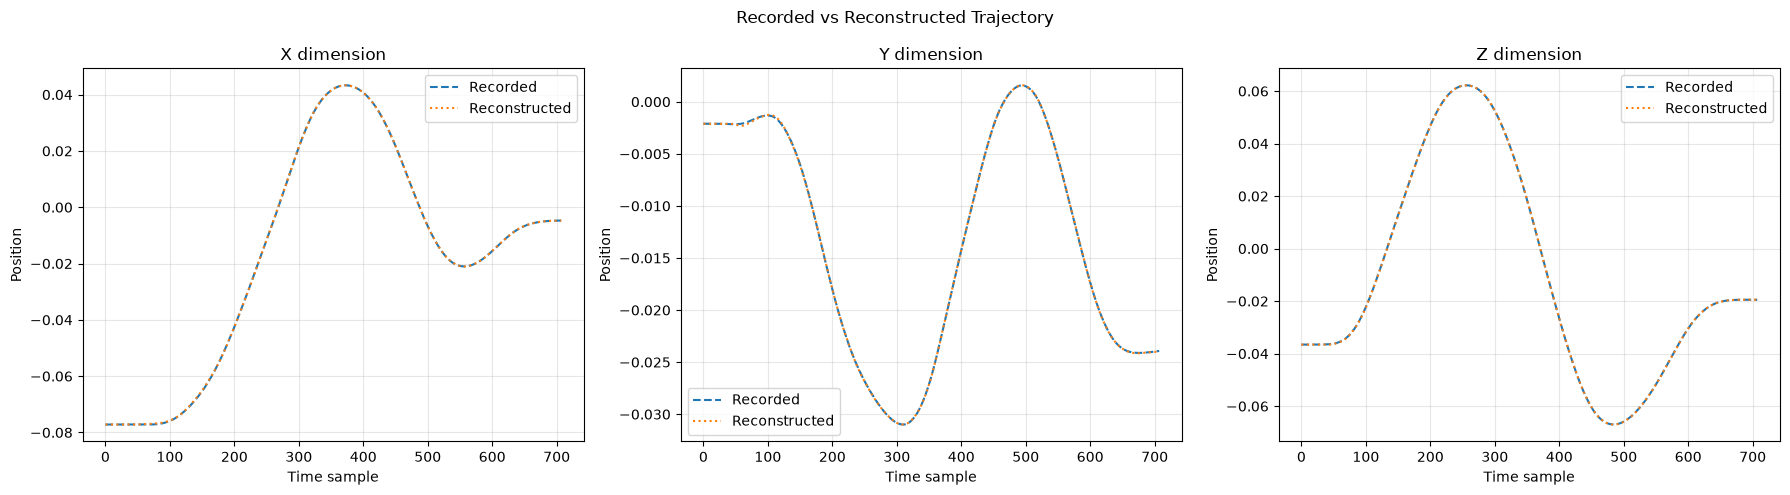

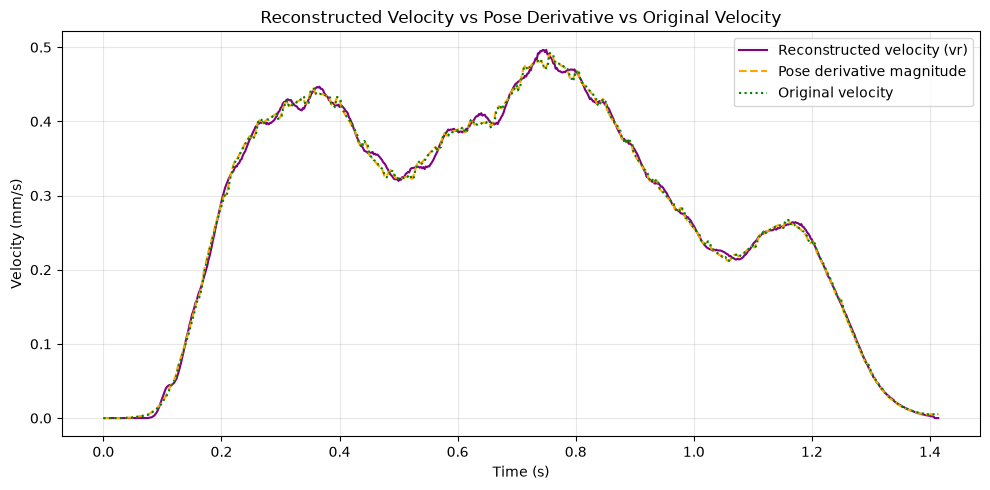

Mean vr: 0.276
Mean pose_derivative: 0.276
Correlation: nan


In [189]:
PICKED_RECORDING_INDEX = 30
from scipy.io import loadmat
PATH_TO_HIGHEST_STROKE_COUNT_CSV = os.path.join(
    os.getcwd(),
    CSV_ROOT,
    stroke_count_db['subject'].iloc[PICKED_RECORDING_INDEX],
    stroke_count_db['task'].iloc[PICKED_RECORDING_INDEX],
    'recording_' + str(stroke_count_db['recording'].iloc[PICKED_RECORDING_INDEX]) + '.csv'
)

PATH_TO_HIGHEST_STROKE_COUNT_MAT = os.path.join(
    os.getcwd(),
    'mat_recording',
    stroke_count_db['subject'].iloc[PICKED_RECORDING_INDEX],
    stroke_count_db['task'].iloc[PICKED_RECORDING_INDEX],
    'recording_' + str(stroke_count_db['recording'].iloc[PICKED_RECORDING_INDEX]) + '.mat'
)

mat_data = loadmat(PATH_TO_HIGHEST_STROKE_COUNT_MAT)

print(f"Path to MAT with highest stroke count: {PATH_TO_HIGHEST_STROKE_COUNT_MAT}")

print(f"Path to CSV with highest stroke count: {PATH_TO_HIGHEST_STROKE_COUNT_CSV}")
csv = pd.read_csv(PATH_TO_HIGHEST_STROKE_COUNT_CSV)
xr,yr,zr = csv['x_reconstructed'], csv['y_reconstructed'], csv['z_reconstructed']
x0,y0,z0 = csv['x_recorded'], csv['y_recorded'], csv['z_recorded']
vr = csv['vr']
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

dimensions = [
    ('x', x0, xr),
    ('y', y0, yr),
    ('z', z0, zr),
]

for ax, (dimension, recorded, reconstructed) in zip(axes, dimensions):
    ax.plot(recorded.index, recorded, label='Recorded', linewidth=1.5, linestyle='--')
    ax.plot(reconstructed.index, reconstructed, label='Reconstructed', linewidth=1.5, linestyle=':')
    ax.set_title(f'{dimension.upper()} dimension')
    ax.set_xlabel('Time sample')
    ax.set_ylabel('Position')
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.suptitle('Recorded vs Reconstructed Trajectory')
plt.tight_layout()
plt.show()

# Calcola il sampling rate (es. 500 Hz se i dati sono acquisiti a 500Hz)
sampling_rate = 500  # o leggilo dai metadati
# Calcola la derivata posizionale in unità fisiche (es. mm/s)
velocity = mat_data['v'].astype(float).tolist()[0]
pose_derivative = np.sqrt(
    np.gradient(x0) ** 2
    + np.gradient(y0) ** 2
    + np.gradient(z0) ** 2
) * sampling_rate  # Moltiplica per il sampling rate per ottenere mm/s
# Crea un array temporale per il plotting
time_axis = np.arange(len(pose_derivative)) / sampling_rate

fig, ax = plt.subplots(figsize=(10, 5))

# Allinea gli indici: se vr ha la stessa lunghezza
ax.plot(
    time_axis,  # Usa il tempo in secondi
    vr,  # Assumendo che vr sia già in mm/s
    label='Reconstructed velocity (vr)',
    color='purple',
    linewidth=1.5
)
ax.plot(
    time_axis,  # Stesso asse temporale
    pose_derivative,
    label='Pose derivative magnitude',
    color='orange',
    linestyle='--',
    linewidth=1.5
)
ax.plot(
    time_axis,  # Stesso asse temporale
    velocity,
    label='Original velocity',
    color='green',
    linestyle=':',
    linewidth=1.5
)

ax.set_title('Reconstructed Velocity vs Pose Derivative vs Original Velocity')
ax.set_xlabel('Time (s)')  # Più significativo di 'Time sample'
ax.set_ylabel('Velocity (mm/s)')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

# Verifica statistica
print(f"Mean vr: {np.mean(vr):.3f}")
print(f"Mean pose_derivative: {np.mean(pose_derivative):.3f}")
print(f"Correlation: {np.corrcoef(vr, pose_derivative)[0,1]:.3f}")

### Frequency Analysis

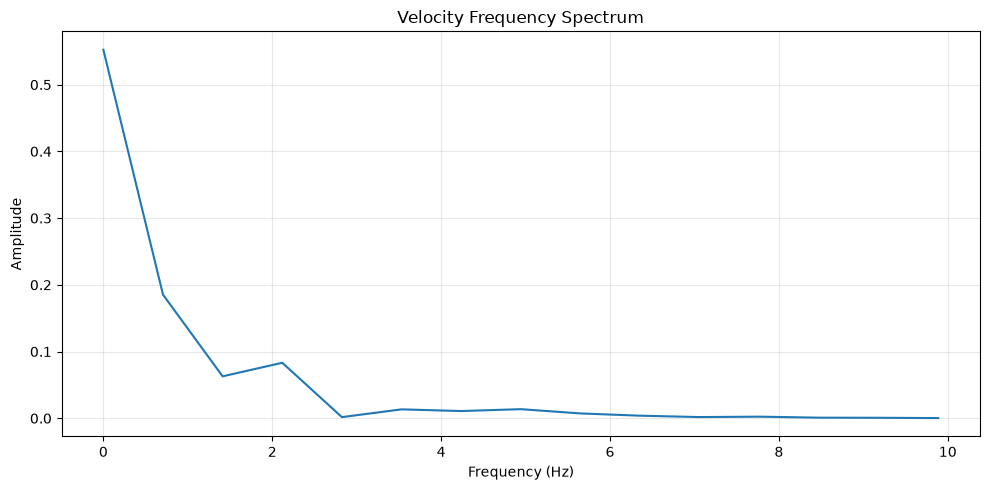

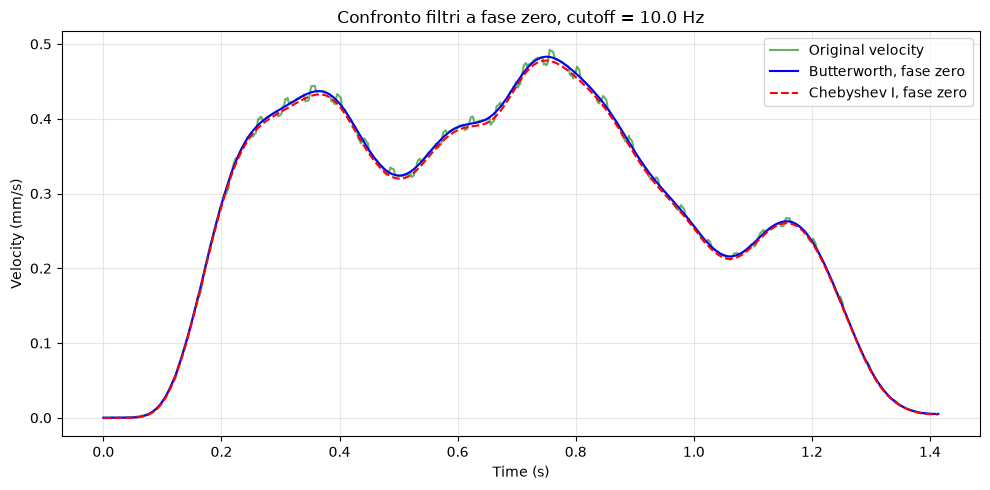

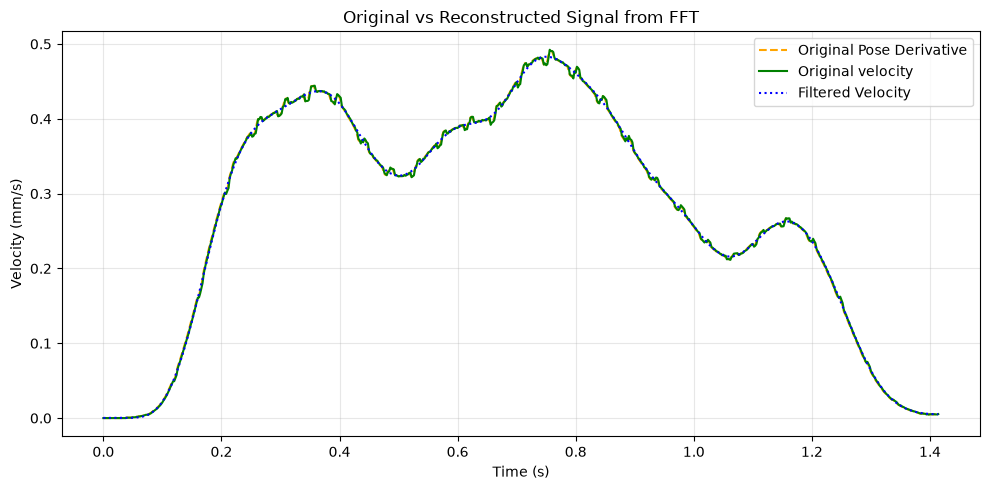

In [ ]:
from numpy.fft import rfft, rfftfreq, irfft
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import cheby1, filtfilt, freqz
from scipy.signal import butter

def cheby1_lowpass_filter(signal, fs, f_cut, order=4, ripple_db=0.5):
    """
    Filtro passa-basso Chebyshev tipo I, zero-phase (filtfilt).

    Parametri
    ----------
    signal   : array 1D
    fs       : frequenza di campionamento [Hz]
    f_cut    : frequenza di taglio (-ripple_db dB) [Hz]
    order    : ordine del filtro (ordine effettivo = 2*order con filtfilt)
    ripple_db: ripple massimo in banda passante [dB]

    Ritorna
    -------
    filtered : segnale filtrato (stessa lunghezza dell'input)
    b, a     : coefficienti del filtro (per analisi)
    """
    nyq = 0.5 * fs
    if not (0 < f_cut < nyq):
        raise ValueError(f"f_cut deve stare in (0, {nyq}) Hz")

    Wn = f_cut / nyq                      # frequenza normalizzata [0,1]
    b, a = cheby1(order, ripple_db, Wn, btype='low')

    # filtfilt: applica forward+backward, zero-phase
    filtered = filtfilt(b, a, signal)
    return filtered, b, a
velocity_freq = rfft(velocity)
HUMAN_FREQUENCY_BAND = (0, 10)  # Frequenze tipiche del movimento umano in Hz
sampling_rate = 500
n = len(pose_derivative)
frequencies = rfftfreq(n, d=1 / sampling_rate)[:len(velocity)]

band_mask = (
    (frequencies >= HUMAN_FREQUENCY_BAND[0])
    & (frequencies <= HUMAN_FREQUENCY_BAND[1])
)

amplitude = 2 * np.abs(velocity_freq) / n

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(frequencies[band_mask], amplitude[band_mask])
ax.set_title('Velocity Frequency Spectrum')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Amplitude')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


chebyhev_order = 4
def cheby1_lowpass_filter(signal, fs, f_cut, order=4, ripple_db=None):
    """Filtro passa-basso Butterworth a fase zero."""
    nyq = 0.5 * fs

    if not (0 < f_cut < nyq):
        raise ValueError(f"f_cut deve stare in (0, {nyq}) Hz")

    b, a = butter(
        N=order,
        Wn=f_cut / nyq,
        btype='low',
        output='ba'
    )

    filtered = filtfilt(b, a, signal)
    return filtered, b, a
# Confronto con un vero filtro Chebyshev I a fase zero
F_CUT = 10.0
FILTER_ORDER = 4
RIPPLE_DB = 0.05

cheby_b, cheby_a = cheby1(
    FILTER_ORDER,
    RIPPLE_DB,
    Wn=F_CUT / (sampling_rate / 2),
    btype='low',
)

cheby_filtered_velocity = filtfilt(cheby_b, cheby_a, velocity)

butter_filtered_velocity, butter_b, butter_a = cheby1_lowpass_filter(
    velocity,
    fs=sampling_rate,
    f_cut=F_CUT,
    order=FILTER_ORDER,
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(time_axis, velocity, label='Original velocity', color='green', alpha=0.6)
ax.plot(
    time_axis,
    butter_filtered_velocity,
    label='Butterworth, fase zero',
    color='blue',
)
ax.plot(
    time_axis,
    cheby_filtered_velocity,
    label='Chebyshev I, fase zero',
    color='red',
    linestyle='--',
)

ax.set_title(f'Confronto filtri a fase zero, cutoff = {F_CUT} Hz')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Velocity (mm/s)')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

F_CUT = 10.0
filtered_velocity, b, a = cheby1_lowpass_filter(
    velocity,
    fs=sampling_rate,
    f_cut=F_CUT,
    order=4,
    ripple_db=0.5,
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(time_axis, pose_derivative, label='Original Pose Derivative', color='orange', linestyle='--', linewidth=1.5)
ax.plot(time_axis, velocity, label='Original velocity', color='green', linewidth=1.5)
ax.plot(time_axis, filtered_velocity, label='Filtered Velocity', color='blue', linestyle=':', linewidth=1.5)
ax.set_title('Original vs Reconstructed Signal from FFT')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Velocity (mm/s)')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

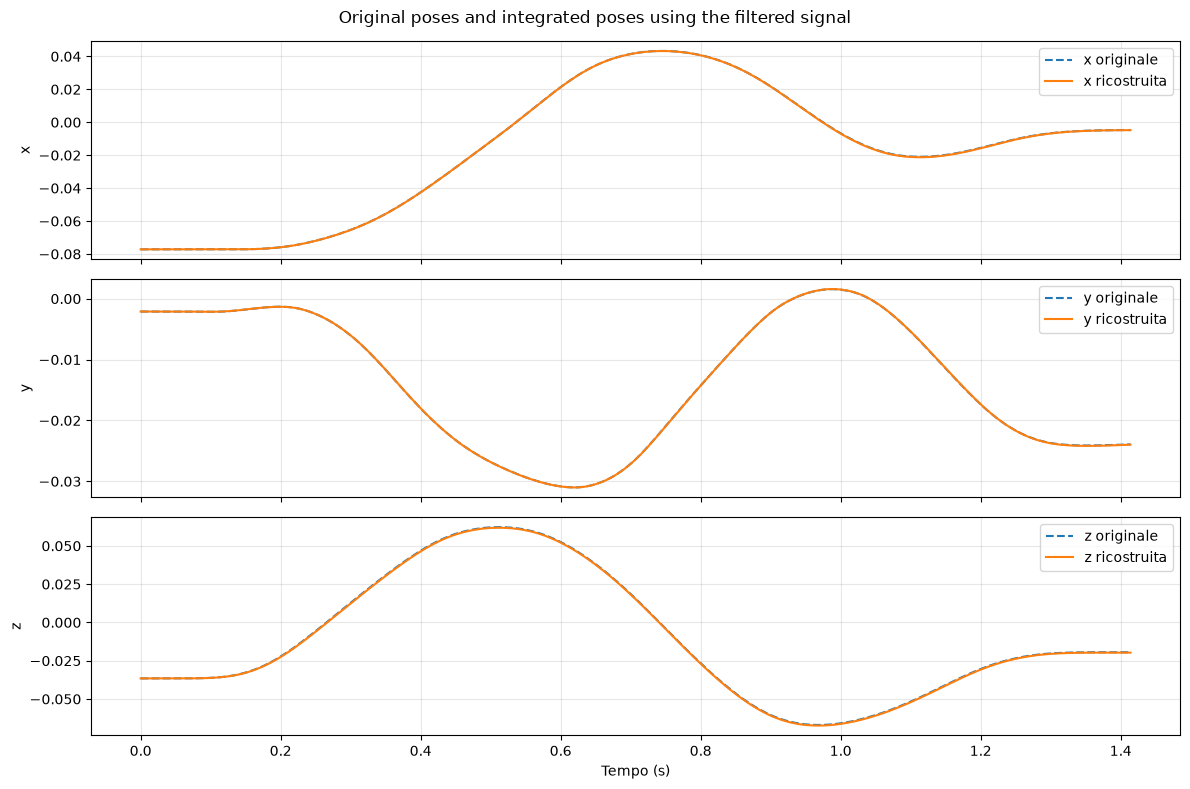

In [191]:
from scipy.integrate import cumulative_trapezoid

pose_initial = np.array([x0.iloc[0], y0.iloc[0], z0.iloc[0]])

x_ref = np.asarray(x0)
y_ref = np.asarray(y0)
z_ref = np.asarray(z0)

dx_dt = np.gradient(x_ref, time_axis)
dy_dt = np.gradient(y_ref, time_axis)
dz_dt = np.gradient(z_ref, time_axis)

norm = np.sqrt(dx_dt**2 + dy_dt**2 + dz_dt**2)

tx = np.divide(dx_dt, norm, out=np.zeros_like(dx_dt), where=norm > 0)
ty = np.divide(dy_dt, norm, out=np.zeros_like(dy_dt), where=norm > 0)
tz = np.divide(dz_dt, norm, out=np.zeros_like(dz_dt), where=norm > 0)

# Segnale filtrato usato direttamente nell'integrazione
speed = np.asarray(filtered_velocity)

vx = speed * tx
vy = speed * ty
vz = speed * tz

x_integrated = pose_initial[0] + cumulative_trapezoid(vx, time_axis, initial=0)
y_integrated = pose_initial[1] + cumulative_trapezoid(vy, time_axis, initial=0)
z_integrated = pose_initial[2] + cumulative_trapezoid(vz, time_axis, initial=0)

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

for ax, original, integrated, label in zip(
    axes,
    [x0, y0, z0],
    [x_integrated, y_integrated, z_integrated],
    ['x', 'y', 'z']
):
    ax.plot(time_axis, np.asarray(original), '--', label=f'{label} originale')
    ax.plot(time_axis, integrated, label=f'{label} ricostruita')
    ax.set_ylabel(label)
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1].set_xlabel('Tempo (s)')
fig.suptitle('Original poses and integrated poses using the filtered signal')
plt.tight_layout()
plt.show()


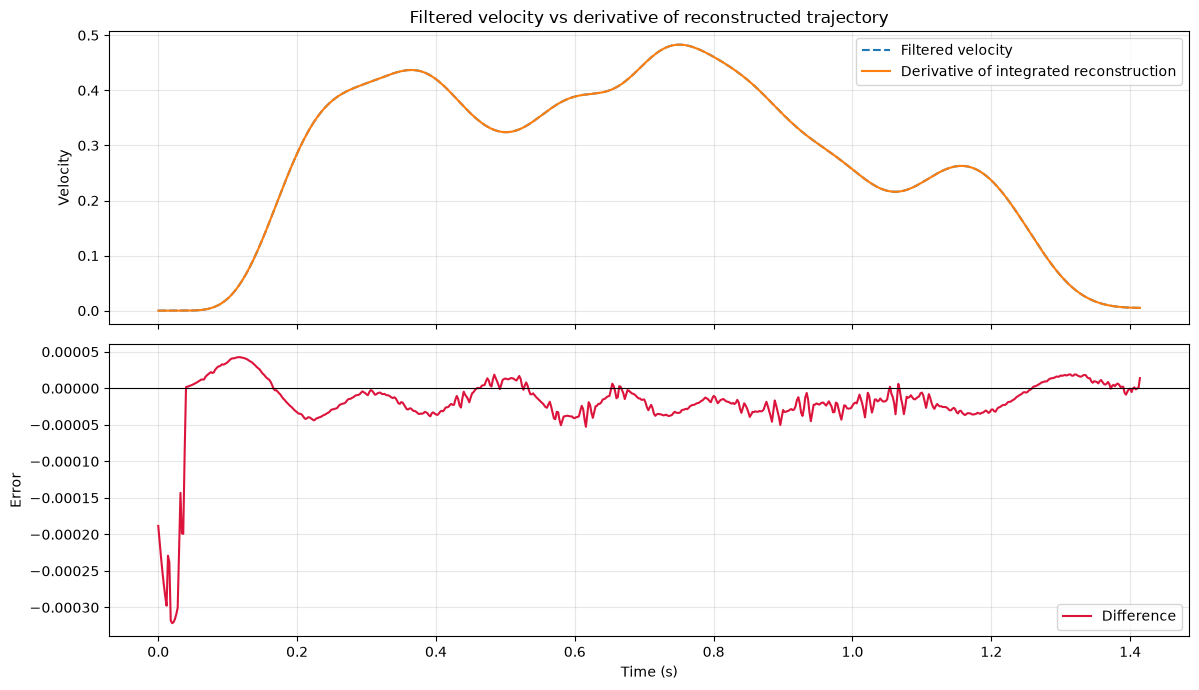

Mean absolute error: 2.72834e-05
Maximum absolute error: 0.00032164
Correlation: 1.000000


In [192]:
# Derivative of the integrated poses
dx_integrated_dt = np.gradient(x_integrated, time_axis)
dy_integrated_dt = np.gradient(y_integrated, time_axis)
dz_integrated_dt = np.gradient(z_integrated, time_axis)

# Reconstructed velocity magnitude
reconstructed_speed = np.sqrt(
    dx_integrated_dt**2
    + dy_integrated_dt**2
    + dz_integrated_dt**2
)

# Compare with the filtered scalar velocity
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(
    time_axis,
    filtered_velocity,
    '--',
    label='Filtered velocity',
    linewidth=1.5
)
axes[0].plot(
    time_axis,
    reconstructed_speed,
    label='Derivative of integrated reconstruction',
    linewidth=1.5
)
axes[0].set_ylabel('Velocity')
axes[0].set_title('Filtered velocity vs derivative of reconstructed trajectory')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(
    time_axis,
    reconstructed_speed - filtered_velocity,
    color='crimson',
    label='Difference'
)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Error')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Mean absolute error: {np.mean(np.abs(reconstructed_speed - filtered_velocity)):.6g}")
print(f"Maximum absolute error: {np.max(np.abs(reconstructed_speed - filtered_velocity)):.6g}")
print(f"Correlation: {np.corrcoef(reconstructed_speed, filtered_velocity)[0, 1]:.6f}")